# How Increased Temperatures Impact Storm Frequency and Intensity

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as dates

## Temperature (Land, Ocean, Combined)

### Land Temperature

In [11]:
land_temp = pd.read_excel("Land Temp Data.xlsx")

In [12]:
land_temp

,Year,Land_Temp_Anomaly
0,1997,0.57
1,1998,0.87
2,1999,0.67
3,2000,0.65
4,2001,0.79
5,2002,0.94
6,2003,0.92
7,2004,0.68
8,2005,1.18
9,2006,1.06


In [13]:
land_temp['Year'] = pd.to_datetime(land_temp.Year, format='%Y')

### Ocean Temperature

In [14]:
ocean_temp = pd.read_excel("Global Ocean Temperature.xlsx")
ocean_temp.rename(columns={"Year (January-December)": "Year", 
                           "Temperature Anomaly (°C)": "Ocean_Temp_Anomaly"}, inplace=True)

In [15]:
ocean_temp

,Year,Ocean_Temp_Anomaly
0,2022,0.67
1,2021,0.63
2,2020,0.72
3,2019,0.74
4,2018,0.66
5,2017,0.69
6,2016,0.75
7,2015,0.72
8,2014,0.61
9,2013,0.51


In [16]:
ocean_temp['Year'] = pd.to_datetime(ocean_temp.Year, format='%Y')

### Land + Ocean Temperature

In [17]:
land_ocean_temp = pd.read_excel("Land Ocean Temp.xlsx")

In [18]:
land_ocean_temp

,Year,Land_Ocean_Anomaly
0,1997,0.50
1,1998,0.63
2,1999,0.42
3,2000,0.43
4,2001,0.55
5,2002,0.62
6,2003,0.63
7,2004,0.55
8,2005,0.70
9,2006,0.66


In [19]:
land_ocean_temp['Year'] = pd.to_datetime(land_ocean_temp.Year, format='%Y')

In [20]:
temp_final = land_ocean_temp.merge(land_temp, how='left', on = 'Year')
temp_final = temp_final.merge(ocean_temp, how = 'left', on = 'Year')

In [21]:
temp_final

,Year,Land_Ocean_Anomaly,Land_Temp_Anomaly,Ocean_Temp_Anomaly
0,1997-01-01,0.50,0.57,0.47
1,1998-01-01,0.63,0.87,0.52
2,1999-01-01,0.42,0.67,0.31
3,2000-01-01,0.43,0.65,0.33
4,2001-01-01,0.55,0.79,0.45
5,2002-01-01,0.62,0.94,0.48
6,2003-01-01,0.63,0.92,0.50
7,2004-01-01,0.55,0.68,0.49
8,2005-01-01,0.70,1.18,0.49
9,2006-01-01,0.66,1.06,0.48


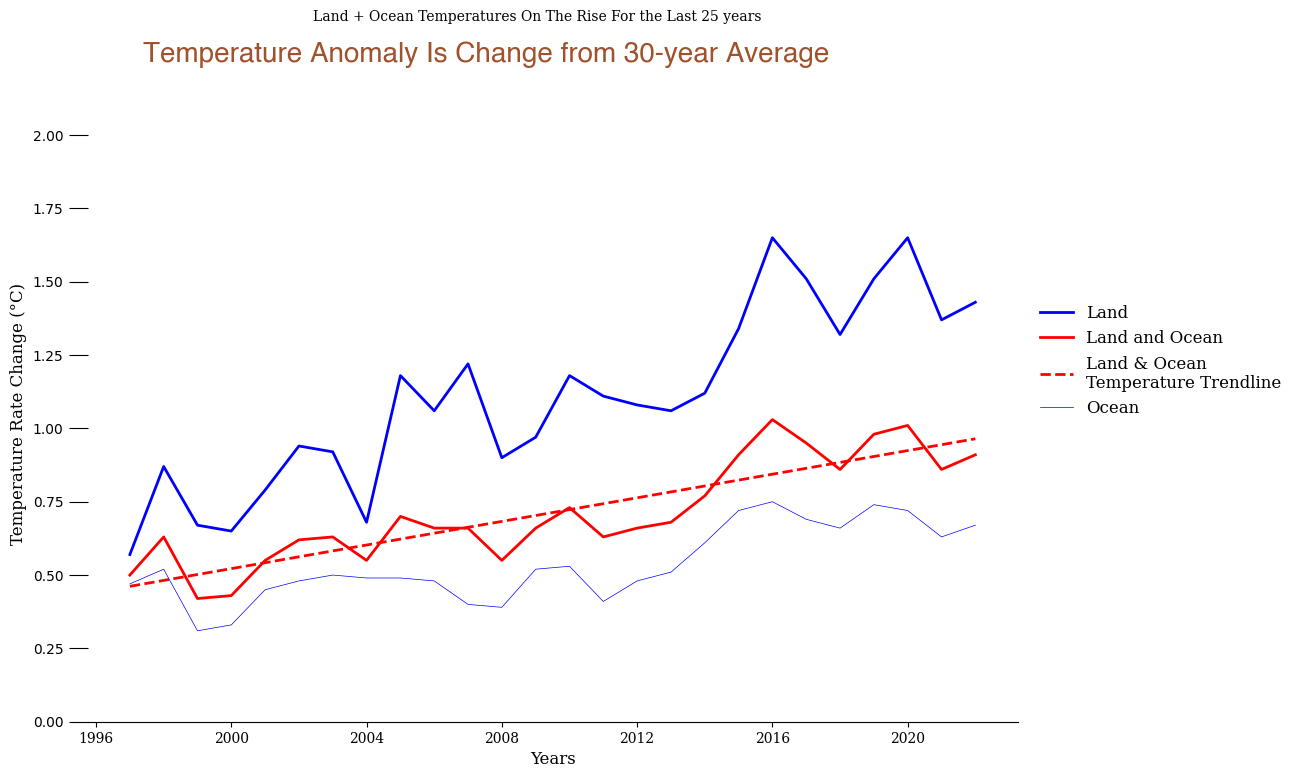

In [22]:
fig, ax1 = plt.subplots(figsize=(12, 8))
#ax2 = ax1.twinx()
#sns.set_style("whitegrid", {'grid.linestyle': '--'})
ax1.plot(temp_final['Year'], temp_final['Land_Temp_Anomaly'], color='blue', lw=2, label = 'Land')
ax1.plot(temp_final['Year'], temp_final['Land_Ocean_Anomaly'], color='red', lw=2, label = 'Land and Ocean')
#ax2.plot(hurricane['Year'], hurricane['Named Storms'], color='green', lw=2, label = 'Named Storms')
#ax2.plot(hurricane['Year'], hurricane['Hurricanes'], color='blue', alpha = 1,lw=2, label = 'Hurricanes')




#ax2.plot(co2['Year'], co2['btons'], color='black',alpha = 1, lw=2, label = u'CO\u2082 Emmision')
plt.xticks(font = 'serif')

x = temp_final['Year']
x_num = dates.date2num(x)
trend = np.polyfit(x_num, temp_final['Land_Ocean_Anomaly'], 1)
fit = np.poly1d(trend)
x_fit = np.linspace(x_num.min(), x_num.max())
plt.plot(dates.num2date(x_fit), fit(x_fit), "r--", label = 'Land & Ocean \nTemperature Trendline', lw = 2)

ax1.plot(temp_final['Year'], temp_final['Ocean_Temp_Anomaly'], color='blue', lw=.5, label = 'Ocean')

ax1.set_ylabel("Temperature Rate Change (°C)", color='black', fontsize=12, fontdict={'font':'serif'})
ax1.set_xlabel("Years", color='black', fontsize=12, fontdict={'font':'serif'})
ax1.tick_params(axis="y", labelcolor='black', size = 14)
ax1.set_ylim(0,2.1)
#ax2.set_ylabel("Carbon Emmision (Billion Tons)", color='black', fontsize=12, fontdict={'font':'serif'})
#ax2.tick_params(axis="y", labelcolor='black')
#ax2.set_ylim(0,55)
fig.suptitle("", fontsize=20)
#fig.autofmt_xdate()
ax1.legend(bbox_to_anchor=(1.3,.47),loc='lower right',prop={'size':12,'family':'serif'}, frameon=False)
#ax2.legend(bbox_to_anchor=(1.29,.4),loc='lower right',prop={'weight':'bold','size':10,'family':'serif'}, frameon=False)
sns.despine(left= True, right = True)
fig.suptitle("Land + Ocean Temperatures On The Rise For the Last 25 years", fontsize=20, color="#000000",font = 'serif', y=1)
ax1.text(10000,2.25,"Temperature Anomaly Is Change from 30-year Average ",
        fontdict={ 'size':20,'family':'Helvetica'}, color="sienna", alpha = 1)

plt.savefig("Earth's Temperature Is On The Rise For last 25 years")
#files.download("Earth's Temperature Is On The Rise For last 25 years.png")

plt.show()

## Carbon Dioxide

In [23]:
carbon_df = pd.read_excel("Carbon Dioxide Data.xlsx")
carbon_df

,year,mean,unc
0,1979,336.85,0.10
1,1980,338.91,0.07
2,1981,340.11,0.08
3,1982,340.85,0.03
4,1983,342.53,0.05
5,1984,344.07,0.07
6,1985,345.54,0.07
7,1986,346.97,0.07
8,1987,348.68,0.09
9,1988,351.16,0.07


In [24]:
carbon_df2 = carbon_df.loc[carbon_df["year"] > 1996]

In [25]:
carbon_df2['year'] = pd.to_datetime(carbon_df2.year, format='%Y')

/var/folders/6m/d853x4qs7139b3m7ydxp7jfm0000gn/T/ipykernel_95166/4076378867.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  carbon_df2['year'] = pd.to_datetime(carbon_df2.year, format='%Y')


In [26]:
carbon_growth = pd.read_excel("CO2 Growth Rate.xlsx")
carbon_growth

,year,Annual Growth PPM,Uncertainty
0,1959,0.96,0.31
1,1960,0.71,0.27
2,1961,0.78,0.27
3,1962,0.56,0.27
4,1963,0.57,0.28
...,...,...,...
59,2018,2.39,0.09
60,2019,2.51,0.06
61,2020,2.34,0.08
62,2021,2.45,0.08


In [27]:
carbon_growth2 = carbon_growth.loc[carbon_growth["year"] > 1996]

In [28]:
carbon_growth2['year'] = pd.to_datetime(carbon_growth2.year, format='%Y')

/var/folders/6m/d853x4qs7139b3m7ydxp7jfm0000gn/T/ipykernel_95166/1657207885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  carbon_growth2['year'] = pd.to_datetime(carbon_growth2.year, format='%Y')


In [29]:
billion_carbon = pd.read_excel("Carbon Emissions Billion Tons.xlsx")

In [30]:
billion_carbon

,Year,Carbon Emissions Billion Tons
0,1940,4.85
1,1941,4.97
2,1942,4.95
3,1943,5.04
4,1944,5.11
...,...,...
78,2018,36.83
79,2019,37.08
80,2020,35.26
81,2021,37.12


In [31]:
billion_carbon2 = billion_carbon.loc[billion_carbon["Year"] > 1996]

In [32]:
billion_carbon2['Year'] = pd.to_datetime(billion_carbon2.Year, format='%Y')

/var/folders/6m/d853x4qs7139b3m7ydxp7jfm0000gn/T/ipykernel_95166/3704678091.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  billion_carbon2['Year'] = pd.to_datetime(billion_carbon2.Year, format='%Y')


In [33]:
billion_carbon2

,Year,Carbon Emissions Billion Tons
57,1997-01-01,24.30
58,1998-01-01,24.21
59,1999-01-01,24.73
60,2000-01-01,25.45
61,2001-01-01,25.67
62,2002-01-01,26.28
63,2003-01-01,27.65
64,2004-01-01,28.64
65,2005-01-01,29.61
66,2006-01-01,30.59


### Carbon Emissions In Billion Metric Tons

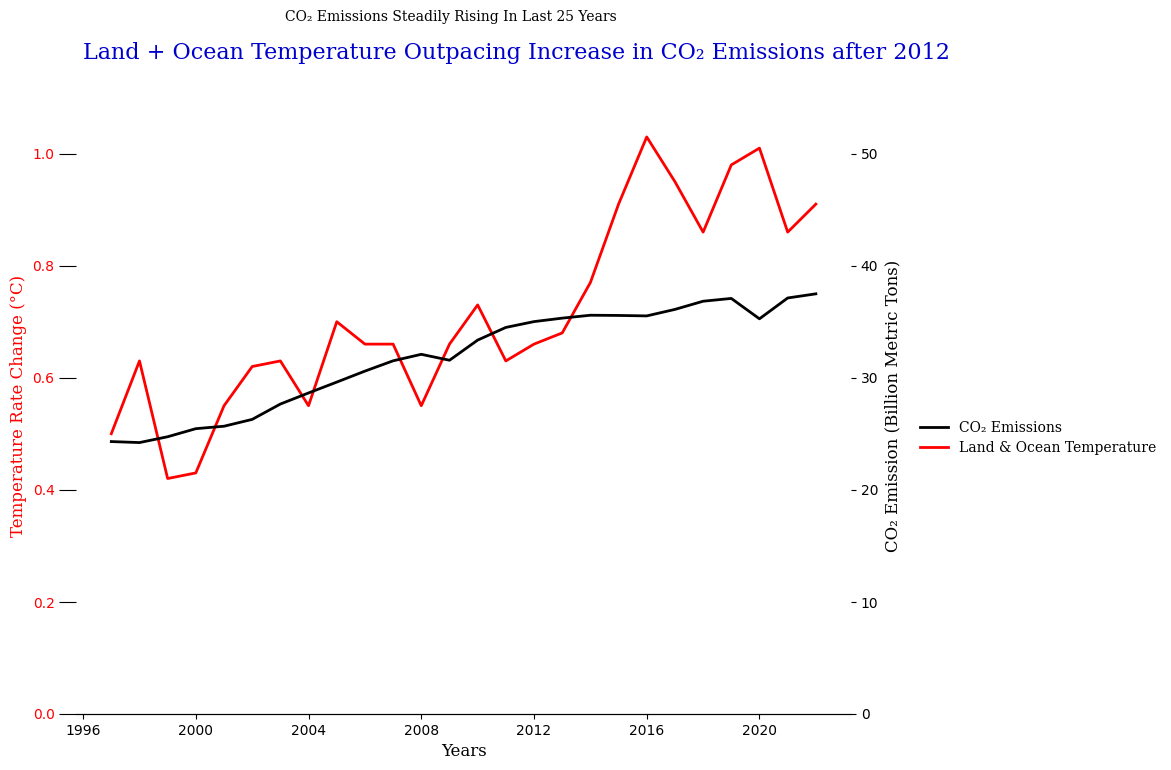

In [34]:
fig, ax1 = plt.subplots(figsize=(10, 8))
ax2 = ax1.twinx()
#sns.set_style("whitegrid", {'grid.linestyle': '--'})

ax1.plot(temp_final['Year'], temp_final['Land_Ocean_Anomaly'], color='red', lw=2, label = 'Land & Ocean Temperature')
#ax2.plot(hurricane['Year'], hurricane['Named Storms'], color='green', lw=2, label = 'Named Storms')
#ax2.plot(hurricane['Year'], hurricane['Hurricanes'], color='blue', alpha = 1,lw=2, label = 'Hurricanes')



ax2.plot(billion_carbon2['Year'], billion_carbon2['Carbon Emissions Billion Tons'], color='black',alpha = 1, lw=2, label = u'CO\u2082 Emissions')
plt.xticks(font = 'serif')
'''
x = billion_carbon2['Year']
x_num = dates.date2num(x)
trend = np.polyfit(x_num, billion_carbon2['Carbon Emissions Billion Metric Tons'], 1)
fit = np.poly1d(trend)
x_fit = np.linspace(x_num.min(), x_num.max())
plt.plot(dates.num2date(x_fit), fit(x_fit), "k--", label = 'CO\u2082 Emission Trendline')
'''


ax1.set_ylabel("Temperature Rate Change (°C)", color='red', fontsize=12, fontdict={'font':'serif'})
ax1.tick_params(axis="y", labelcolor='red', size = 12)
ax1.set_ylim(0,1.1)
ax2.set_ylabel("CO\u2082 Emission (Billion Metric Tons)", color='black', fontsize=12, fontdict={'font':'serif'})
ax1.set_xlabel("Years", color='black', fontsize=12, fontdict={'font':'serif'})
ax2.tick_params(axis="y", labelcolor='black')
ax2.set_ylim(0,55)
fig.suptitle("", fontsize=20)
#fig.autofmt_xdate()
ax1.legend(bbox_to_anchor=(1.41,.4),loc='lower right',prop={'size':10,'family':'serif'}, frameon=False)
ax2.legend(bbox_to_anchor=(1.288,.432),loc='lower right',prop={'size':10,'family':'serif'}, frameon=False)
sns.despine(left= True)
fig.suptitle("CO\u2082 Emissions Steadily Rising In Last 25 Years", fontsize=16, font = 'serif', color="#000000", y = .99)
ax1.text(9500,1.17,"Land + Ocean Temperature Outpacing Increase in CO\u2082 Emissions after 2012",
        fontdict={ 'size':16,'family':'serif'}, color="mediumblue", alpha = 1)

plt.show()

### Annual Growth Rate of Carbon Emissions

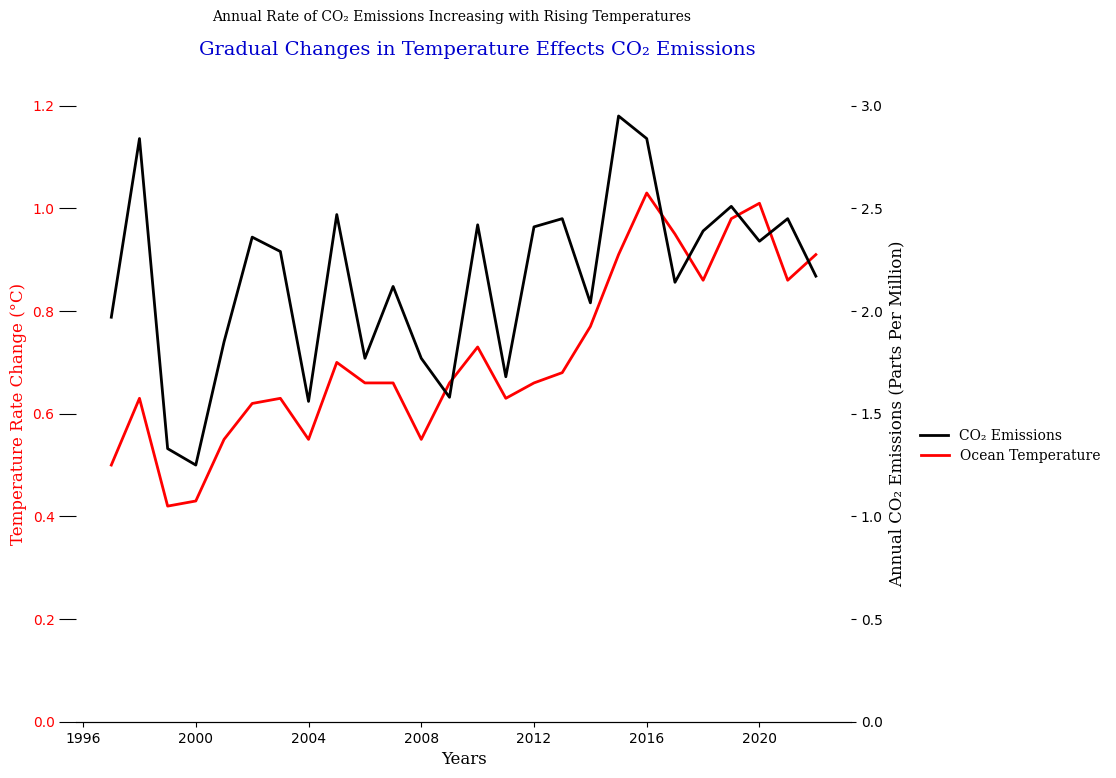

In [35]:
fig, ax1 = plt.subplots(figsize=(10, 8))
ax2 = ax1.twinx()
#sns.set_style("whitegrid", {'grid.linestyle': '--'})

ax1.plot(temp_final['Year'], temp_final['Land_Ocean_Anomaly'], color='red', lw=2, label = 'Ocean Temperature')
#ax2.plot(hurricane['Year'], hurricane['Named Storms'], color='green', lw=2, label = 'Named Storms')
#ax2.plot(hurricane['Year'], hurricane['Hurricanes'], color='blue', alpha = 1,lw=2, label = 'Hurricanes')



ax2.plot(carbon_growth2['year'], carbon_growth2['Annual Growth PPM'], color='black',alpha = 1, lw=2, label = u'CO\u2082 Emissions')
plt.xticks(font = 'serif')
'''
x = carbon_growth2['Year']
x_num = dates.date2num(x)
trend = np.polyfit(x_num, carbon_growth2['Annual Growth PPM'], 1)
fit = np.poly1d(trend)
x_fit = np.linspace(x_num.min(), x_num.max())
plt.plot(dates.num2date(x_fit), fit(x_fit), "k--", label = 'CO\u2082 Emission Trendline')
'''


ax1.set_ylabel("Temperature Rate Change (°C)", color='red', fontsize=12, fontdict={'font':'serif'})
ax1.tick_params(axis="y", labelcolor='red', size = 12)
ax1.set_ylim(0,1.2)
ax2.set_ylabel("Annual CO\u2082 Emissions (Parts Per Million)", color='black', fontsize=12, fontdict={'font':'serif'})
ax1.set_xlabel("Years", color='black', fontsize=12, fontdict={'font':'serif'})
ax2.tick_params(axis="y", labelcolor='black')
ax2.set_ylim(0,3)
fig.suptitle("", fontsize=20)
#fig.autofmt_xdate()
ax1.legend(bbox_to_anchor=(1.338,.4),loc='lower right',prop={'size':10,'family':'serif'}, frameon=False)
ax2.legend(bbox_to_anchor=(1.288,.432),loc='lower right',prop={'size':10,'family':'serif'}, frameon=False)
sns.despine(left= True)
fig.suptitle("Annual Rate of CO\u2082 Emissions Increasing with Rising Temperatures", fontsize=16, font = 'serif', color="#000000", y = 1)
ax1.text(11000,1.3,"Gradual Changes in Temperature Effects CO\u2082 Emissions",
        fontdict={ 'size':14,'family':'serif'}, color="mediumblue", alpha = 1)

plt.show()

In [36]:
billion_carbon2.reset_index()

,index,Year,Carbon Emissions Billion Tons
0,57,1997-01-01,24.30
1,58,1998-01-01,24.21
2,59,1999-01-01,24.73
3,60,2000-01-01,25.45
4,61,2001-01-01,25.67
5,62,2002-01-01,26.28
6,63,2003-01-01,27.65
7,64,2004-01-01,28.64
8,65,2005-01-01,29.61
9,66,2006-01-01,30.59


In [37]:
temp_final

,Year,Land_Ocean_Anomaly,Land_Temp_Anomaly,Ocean_Temp_Anomaly
0,1997-01-01,0.50,0.57,0.47
1,1998-01-01,0.63,0.87,0.52
2,1999-01-01,0.42,0.67,0.31
3,2000-01-01,0.43,0.65,0.33
4,2001-01-01,0.55,0.79,0.45
5,2002-01-01,0.62,0.94,0.48
6,2003-01-01,0.63,0.92,0.50
7,2004-01-01,0.55,0.68,0.49
8,2005-01-01,0.70,1.18,0.49
9,2006-01-01,0.66,1.06,0.48


## Hurricanes

In [38]:
hurricanes_df = pd.read_csv("hurricanes data - Sheet1.csv")
hurricanes_df.rename(columns={"Year ▾": "Year"}, inplace=True)

In [39]:
hurricanes_df

,Year,Named Storms,Named Storm Days,Hurricanes,Hurricanes Days,Cat. 3+ Hurricanes,Cat. 3+ Hurricanes Days,Accumulated Cyclone Energy
0,1980,73,367.25,43,143.75,19,30.25,638.0
1,1981,82,363.75,45,125.75,15,19.50,554.7
2,1982,81,428.75,46,162.25,21,37.75,709.2
3,1983,79,369.50,42,150.00,21,47.25,680.0
4,1984,93,439.00,47,160.25,20,41.25,726.2
5,1985,95,455.25,51,163.50,24,27.75,717.8
6,1986,88,407.75,48,172.25,16,31.00,695.0
7,1987,83,400.75,39,133.75,18,39.75,649.1
8,1988,74,336.25,39,146.00,19,41.25,625.4
9,1989,91,440.00,55,199.25,25,56.75,853.9


In [40]:
hurricanes_df = hurricanes_df.loc[hurricanes_df["Year"] > 1996]

In [41]:
hurricanes_df['Year'] = pd.to_datetime(hurricanes_df.Year, format='%Y')

/var/folders/6m/d853x4qs7139b3m7ydxp7jfm0000gn/T/ipykernel_95166/2292939483.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hurricanes_df['Year'] = pd.to_datetime(hurricanes_df.Year, format='%Y')


### Accumulated Cyclone Energy

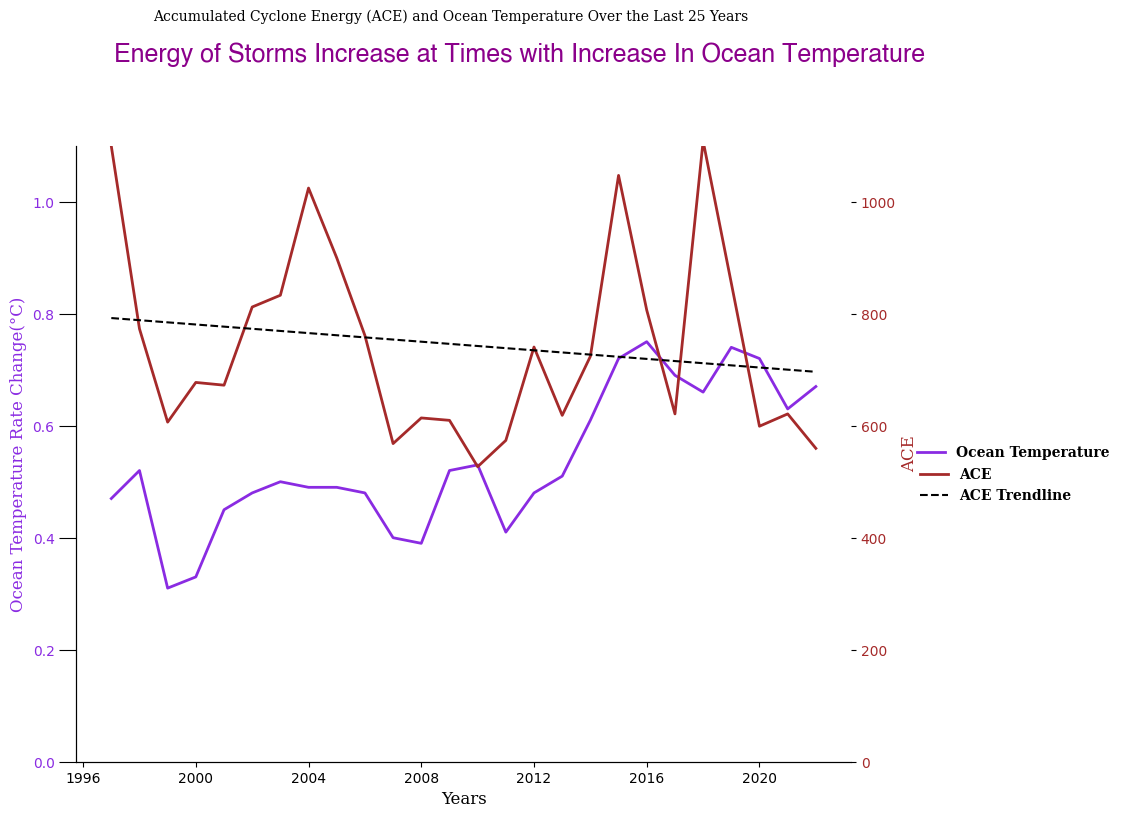

In [42]:
fig, ax1 = plt.subplots(figsize=(10, 8))
ax2 = ax1.twinx()
#sns.set_style("whitegrid", {'grid.linestyle': '--'})

ax1.plot(temp_final['Year'], temp_final['Ocean_Temp_Anomaly'], color='blueviolet', lw=2, label = 'Ocean Temperature')
#ax2.plot(hurricane['Year'], hurricane['Named Storms'], color='green', lw=2, label = 'Named Storms')
#ax2.plot(hurricane['Year'], hurricane['Hurricanes'], color='blue', alpha = 1,lw=2, label = 'Hurricanes')



ax2.plot(hurricanes_df['Year'], hurricanes_df['Accumulated Cyclone Energy'], color='brown',alpha = 1, lw=2, label = 'ACE')
plt.xticks(font = 'serif')

x = hurricanes_df['Year']
x_num = dates.date2num(x)
trend = np.polyfit(x_num, hurricanes_df['Accumulated Cyclone Energy'], 1)
fit = np.poly1d(trend)
x_fit = np.linspace(x_num.min(), x_num.max())
plt.plot(dates.num2date(x_fit), fit(x_fit), "k--", label = 'ACE Trendline')


ax1.set_ylabel("Ocean Temperature Rate Change(°C)", color='blueviolet', fontsize=12, fontdict={'font':'serif'})
ax1.tick_params(axis="y", labelcolor='blueviolet', size = 12)
ax1.set_ylim(0,1.1)
ax2.set_ylabel("ACE", color='brown', fontsize=12, fontdict={'font':'serif'})
ax1.set_xlabel("Years", color='black', fontsize=12, fontdict={'font':'serif'})
ax2.tick_params(axis="y", labelcolor='brown')
ax2.set_ylim(0,1100)
fig.suptitle("", fontsize=20)
#fig.autofmt_xdate()
ax1.legend(bbox_to_anchor=(1.35,.47),loc='lower right',prop={'weight':'bold','size':10,'family':'serif'}, frameon=False)
ax2.legend(bbox_to_anchor=(1.3,.4),loc='lower right',prop={'weight':'bold','size':10,'family':'serif'}, frameon=False)
sns.despine(bottom = False, left = False)
fig.suptitle("Accumulated Cyclone Energy (ACE) and Ocean Temperature Over the Last 25 Years", fontsize=16, font = 'serif', color="#000000", y = 1.05)
ax1.text(9900,1.25,"Energy of Storms Increase at Times with Increase In Ocean Temperature",
       fontdict={ 'size':18,'family':'Helvetica'}, color="darkmagenta", alpha = 1)
plt.show()

### Category 3+ Hurricanes

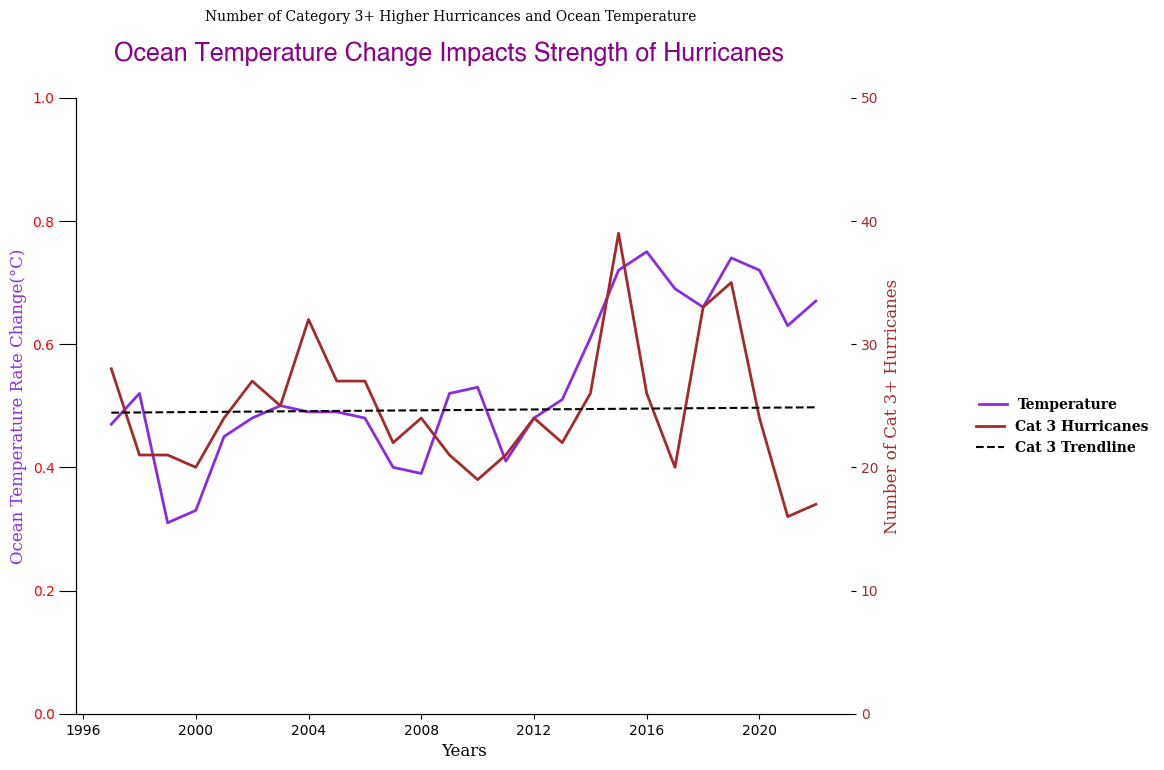

In [43]:
fig, ax1 = plt.subplots(figsize=(10, 8))
ax2 = ax1.twinx()
#sns.set_style("whitegrid", {'grid.linestyle': '--'})

ax1.plot(temp_final['Year'], temp_final['Ocean_Temp_Anomaly'], color='blueviolet', lw=2, label = 'Temperature')
#ax2.plot(hurricane['Year'], hurricane['Named Storms'], color='green', lw=2, label = 'Named Storms')
#ax2.plot(hurricane['Year'], hurricane['Hurricanes'], color='blue', alpha = 1,lw=2, label = 'Hurricanes')



ax2.plot(hurricanes_df['Year'], hurricanes_df['Cat. 3+ Hurricanes'], color='brown',alpha = 1, lw=2, label = 'Cat 3 Hurricanes')
plt.xticks(font = 'serif')

x = hurricanes_df['Year']
x_num = dates.date2num(x)
trend = np.polyfit(x_num, hurricanes_df['Cat. 3+ Hurricanes'], 1)
fit = np.poly1d(trend)
x_fit = np.linspace(x_num.min(), x_num.max())
plt.plot(dates.num2date(x_fit), fit(x_fit), "k--", label = 'Cat 3 Trendline')


ax1.set_ylabel("Ocean Temperature Rate Change(°C)", color='blueviolet', fontsize=12, fontdict={'font':'serif'})
ax1.tick_params(axis="y", labelcolor='red', size = 12)
ax1.set_ylim(0,1)
ax2.set_ylabel("Number of Cat 3+ Hurricanes", color='brown', fontsize=12, fontdict={'font':'serif'})
ax1.set_xlabel("Years", color='black', fontsize=12, fontdict={'font':'serif'})
ax2.tick_params(axis="y", labelcolor='brown')
ax2.set_ylim(0,50)
fig.suptitle("", fontsize=20)
#fig.autofmt_xdate()
ax1.legend(bbox_to_anchor=(1.36,.47),loc='lower right',prop={'weight':'bold','size':10,'family':'serif'}, frameon=False)
ax2.legend(bbox_to_anchor=(1.4,.4),loc='lower right',prop={'weight':'bold','size':10,'family':'serif'}, frameon=False)
sns.despine(bottom = False, left = False)
fig.suptitle("Number of Category 3+ Higher Hurricances and Ocean Temperature", fontsize=16, font = 'serif', color="#000000",y = .99)
ax1.text(9900,1.06,"Ocean Temperature Change Impacts Strength of Hurricanes",
       fontdict={ 'size':18,'family':'Helvetica'}, color="darkmagenta",alpha = 1)
plt.show()

### Number of Total Hurricanes

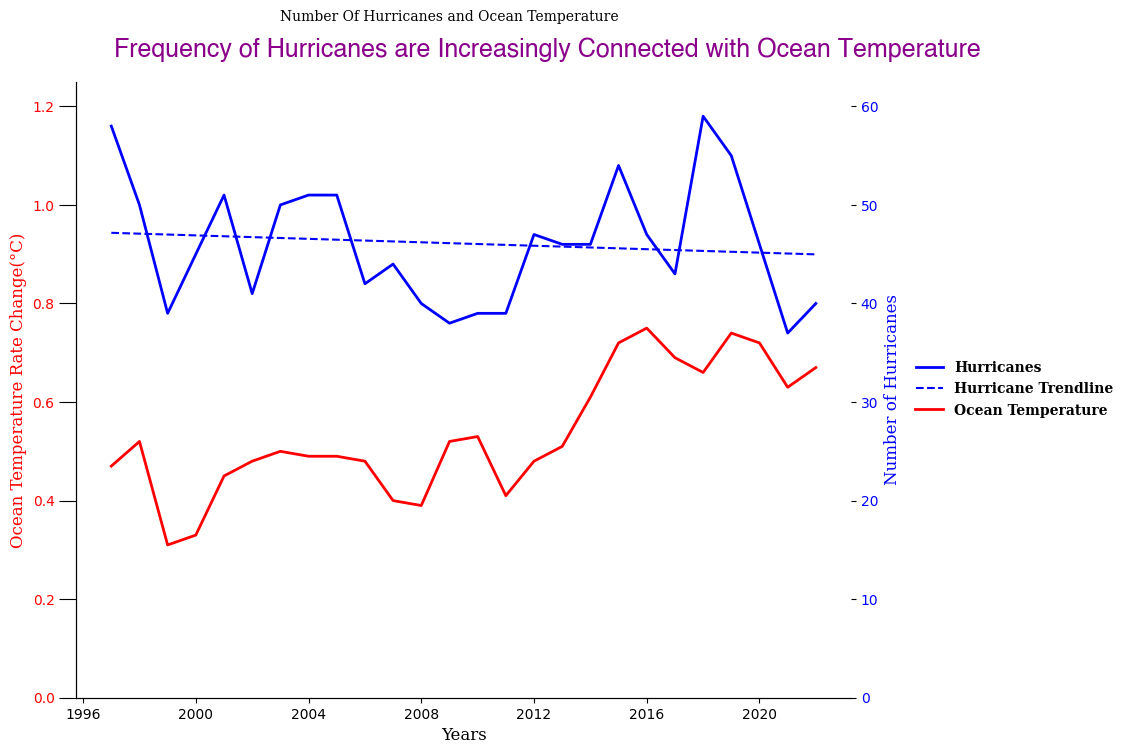

In [44]:
fig, ax1 = plt.subplots(figsize=(10, 8))
ax2 = ax1.twinx()
#sns.set_style("whitegrid", {'grid.linestyle': '--'})

ax1.plot(temp_final['Year'], temp_final['Ocean_Temp_Anomaly'], color='red', lw=2, label = 'Ocean Temperature')
#ax2.plot(hurricane['Year'], hurricane['Named Storms'], color='green', lw=2, label = 'Named Storms')
ax2.plot(hurricanes_df['Year'], hurricanes_df['Hurricanes'], color='blue', alpha = 1,lw=2, label = 'Hurricanes')
x = hurricanes_df['Year']
x_num = dates.date2num(x)
trend = np.polyfit(x_num, hurricanes_df['Hurricanes'], 1)
fit = np.poly1d(trend)
x_fit = np.linspace(x_num.min(), x_num.max())
plt.plot(dates.num2date(x_fit), fit(x_fit), "b--", label = 'Hurricane Trendline')


#ax2.plot(hurricane['Year'], hurricane['Cat. 3+ Hurricanes'], color='black',alpha = .3, lw=1, label = 'Category 3+ Hurricanes')
plt.xticks(font = 'serif')



ax1.set_ylabel("Ocean Temperature Rate Change(°C)", color='red', fontsize=12, fontdict={'font':'serif'})
ax1.tick_params(axis="y", labelcolor='red', size = 12)
ax1.set_ylim(0,1.25)
ax2.set_ylabel("Number of Hurricanes", color='blue', fontsize=12, fontdict={'font':'serif'})
ax1.set_xlabel("Years", color='black', fontsize=12, fontdict={'font':'serif'})
ax2.tick_params(axis="y", labelcolor='blue')
ax2.set_ylim(0,62.5)
fig.suptitle("", fontsize=20)
#fig.autofmt_xdate()
ax1.legend(bbox_to_anchor=(1.347,.435),loc='lower right',prop={'weight':'bold','size':10,'family':'serif'}, frameon=False)
ax2.legend(bbox_to_anchor=(1.355,.47),loc='lower right',prop={'weight':'bold','size':10,'family':'serif'}, frameon=False)
sns.despine(bottom = False, left = False)
fig.suptitle("Number Of Hurricanes and Ocean Temperature ", fontsize=16, font = 'serif', color="#000000", y = .97)
ax1.text(9900,1.3,"Frequency of Hurricanes are Increasingly Connected with Ocean Temperature",
        fontdict={ 'size':18,'family':'Helvetica'}, color="darkmagenta", alpha = 1)
plt.show()

### Named Storms

In [45]:
cause1 = ocean_temp.loc[ocean_temp['Year']>='2000-01-01' ]
cause1 = cause1.loc[ocean_temp['Year']<='2004-01-01']
cause2 = ocean_temp.loc[ocean_temp['Year']>='2010-01-01' ]
cause2 = cause2.loc[cause2['Year']<='2012-01-01']

effect1 = hurricanes_df.loc[hurricanes_df['Year']>='2002-01-01' ]
effect1 = effect1.loc[effect1['Year']<='2005-01-01' ]
effect2 = hurricanes_df.loc[hurricanes_df['Year']>='2012-01-01' ]
effect2 = effect2.loc[effect2['Year']<='2014-01-01' ]

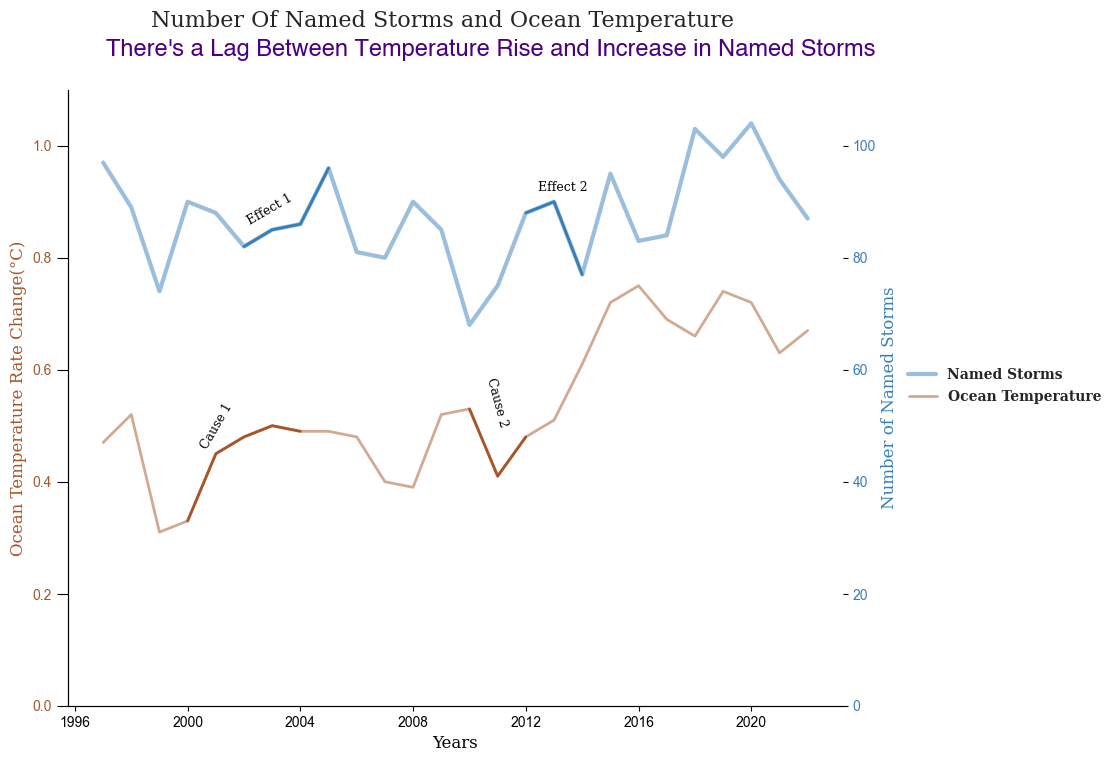

In [46]:
fig, ax1 = plt.subplots(figsize=(10, 8))
ax2 = ax1.twinx()
sns.set_style("whitegrid", {'grid.linestyle': '--'})


ax2.plot(hurricanes_df['Year'], hurricanes_df['Named Storms'], color='#377eb8', alpha = .5, lw=3, label = 'Named Storms')
ax2.plot(effect1['Year'], effect1['Named Storms'], color='#377eb8', alpha = 1, lw=2)
ax2.plot(effect2['Year'], effect2['Named Storms'], color='#377eb8', alpha = 1, lw=2)
'''
x = hurricanes_df['Year']
x_num = dates.date2num(x)
trend = np.polyfit(x_num, hurricanes_df['Named Storms'], 1)
fit = np.poly1d(trend)
x_fit = np.linspace(x_num.min(), x_num.max())
plt.plot(dates.num2date(x_fit), fit(x_fit), "g--", label = 'Named Storms Trendline', lw = 2)
'''
#ax2.plot(hurricane['Year'], hurricane['Hurricanes'], color='blue', alpha = .3,lw=1, label = 'Hurricanes')
ax1.plot(ocean_temp['Year'], ocean_temp['Ocean_Temp_Anomaly'], color='#a65628', lw=2, alpha = .5, label = 'Ocean Temperature')
ax1.plot(cause1['Year'], cause1['Ocean_Temp_Anomaly'], color='#a65628', lw=2)
ax1.plot(cause2['Year'], cause2['Ocean_Temp_Anomaly'], color='#a65628', lw=2)
#ax2.plot(hurricane['Year'], hurricane['Cat. 3+ Hurricanes'], color='black',alpha = .3, lw=1, label = 'Category 3+ Hurricanes')
plt.xticks(font = 'serif')



ax1.set_ylabel("Ocean Temperature Rate Change(°C)", color='#a65628', fontsize=12, fontdict={'font':'serif'})
ax1.tick_params(axis="y", labelcolor='#a65628', size = 8)
ax1.set_ylim(0,1.1)
ax2.set_ylabel("Number of Named Storms", color='#377eb8', fontsize=12, fontdict={'font':'serif'})
ax1.set_xlabel("Years", color='black', fontsize=12, fontdict={'font':'serif'})
ax2.tick_params(axis="y", labelcolor='#377eb8')
ax2.set_ylim(0,110)

#fig.autofmt_xdate()

ax2.legend(bbox_to_anchor=(1.3,.505),loc='lower right',prop={'weight':'bold','size':10,'family':'serif'}, frameon=False)
ax1.legend(bbox_to_anchor=(1.35,.47),loc='lower right',prop={'weight':'bold','size':10,'family':'serif'}, frameon=False)
sns.despine(bottom = False, left = False)
fig.suptitle("Number Of Named Storms and Ocean Temperature", fontsize=16, font = 'serif', y = .98)
ax1.text(9900,1.16,"There's a Lag Between Temperature Rise and Increase in Named Storms",
       fontdict={ 'size':17,'family':'Helvetica', 'color':'indigo'})
ax1.text(11100,.46,"Cause 1",fontdict={ 'size':11,'family':'serif', 'color':'#000000'}, rotation=60, size=9)
ax1.text(11700,.86,"Effect 1",fontdict={ 'size':11,'family':'serif', 'color':'#000000'}, rotation=30, size=9)
ax1.text(14800,.5,"Cause 2",fontdict={ 'size':11,'family':'serif', 'color':'#000000'}, rotation=285, size=9)
ax1.text(15500,.92,"Effect 2",fontdict={ 'size':11,'family':'serif', 'color':'#000000'}, rotation=0, size=9)



plt.show()

## Antarctic and Greenland Ice Mass

In [47]:
glacier_df = pd.read_excel("greenland-and-antarctica-ice-sheet-mass-copy.xlsx")

In [48]:
glacier_df.rename(columns={"Greenland Ice Mass Variation (Gt)": "Greenland_Ice_Mass_Variation",
                  "Antartica Ice Mass Variation (Gt)": "Antartica_Ice_Mass_Variation"},inplace=True)

In [49]:
glacier_df.rename(columns={"Antartica  Ice Mass Variation (Gt)": "Antartica_Ice_Mass_Variation"},inplace=True)

In [50]:
glacier_df['Year'] = pd.to_datetime(glacier_df.Year, format='%Y')

In [51]:
glacier_df

,Year,Greenland_Ice_Mass_Variation,Greenland Uncertainty (+/- Gt),Antartica_Ice_Mass_Variation,Antarctica Uncertainty (+/- Gt)
0,2002-01-01,0.00,134.28,0.00,178.90
1,2002-01-01,68.44,70.59,18.97,102.47
2,2002-01-01,-220.42,53.36,-59.44,83.09
3,2002-01-01,-241.73,64.95,44.20,97.19
4,2002-01-01,-209.72,39.05,62.79,61.82
...,...,...,...,...,...
208,2022-01-01,-5090.29,22.86,-2284.22,33.45
209,2022-01-01,-5073.67,28.99,-2306.01,39.56
210,2022-01-01,-5176.95,36.03,-2416.69,46.74
211,2022-01-01,-5291.31,43.49,-2375.16,55.50


In [52]:
temp_final2 = temp_final.loc[temp_final["Year"] > "2001-01-01"]

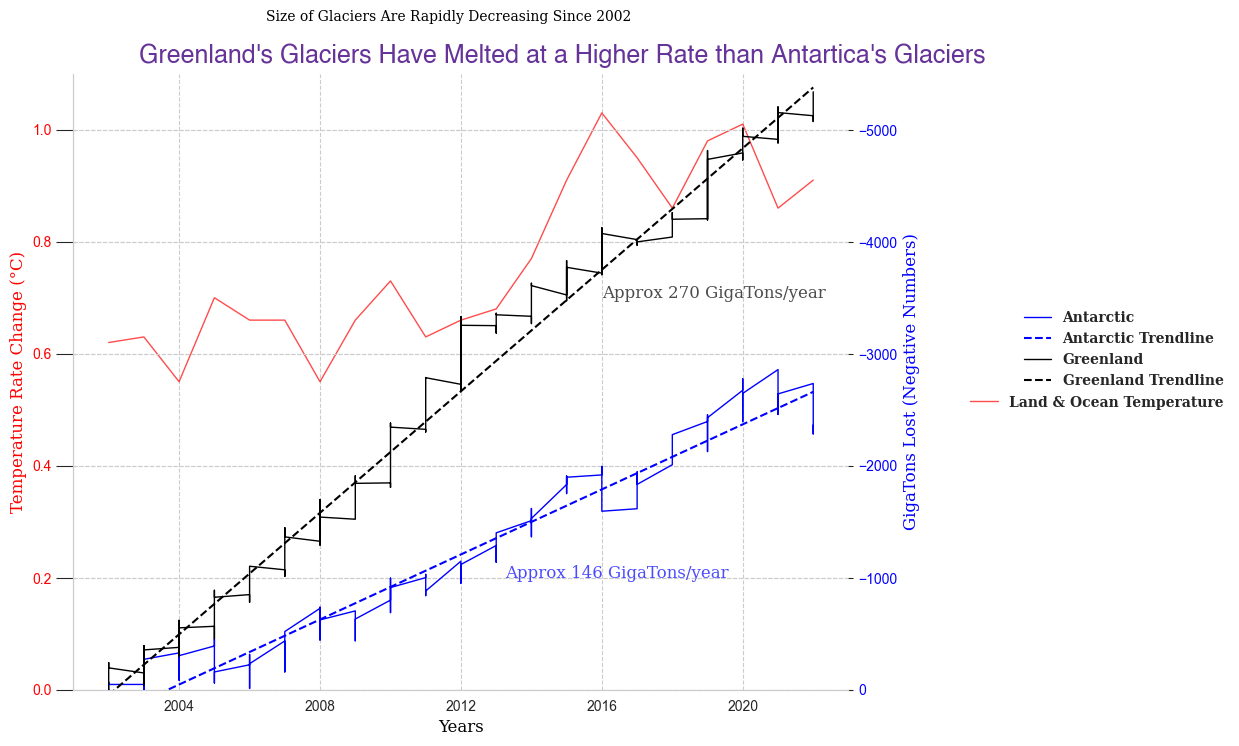

In [53]:
fig, ax1 = plt.subplots(figsize=(10, 8))
ax2 = ax1.twinx()
#sns.set_style("whitegrid", {'grid.linestyle': '--'})


#ax2.plot(hurricane['Year'], hurricane['Named Storms'], color='green', lw=2, label = 'Named Storms')
ax2.plot(glacier_df['Year'], glacier_df["Antartica_Ice_Mass_Variation"], color='blue', alpha = 1,lw=1, label = 'Antarctic')


x = glacier_df['Year']
x_num = dates.date2num(x)
trend = np.polyfit(x_num, glacier_df['Antartica_Ice_Mass_Variation'], 1)
fit = np.poly1d(trend)
x_fit = np.linspace(x_num.min(), x_num.max())
plt.plot(dates.num2date(x_fit), fit(x_fit), "b--", label = 'Antarctic Trendline')

ax2.plot(glacier_df['Year'], glacier_df['Greenland_Ice_Mass_Variation'], color='black', lw=1, label = 'Greenland')

x = glacier_df['Year']
x_num = dates.date2num(x)
trend = np.polyfit(x_num, glacier_df['Greenland_Ice_Mass_Variation'], 1)
fit = np.poly1d(trend)
x_fit = np.linspace(x_num.min(), x_num.max())
plt.plot(dates.num2date(x_fit), fit(x_fit), "k--", label = 'Greenland Trendline')

ax1.plot(temp_final2['Year'], temp_final2['Land_Ocean_Anomaly'], color='red',alpha = .7, lw=1, label = 'Land & Ocean Temperature')
plt.xticks(font = 'serif')

a = temp_final2['Year']
a_num = dates.date2num(a)
trend = np.polyfit(a_num, temp_final2['Land_Ocean_Anomaly'], 1)
fit = np.poly1d(trend)
x_fit = np.linspace(a_num.min(), a_num.max())
#plt.plot(dates.num2date(x_fit), fit(x_fit), "r--", label = 'Temperature Trendline')

ax1.set_ylabel("Temperature Rate Change (°C)", color='red', fontsize=12, fontdict={'font':'serif'})
ax1.tick_params(axis="y", labelcolor='red', size = 12)
ax1.set_ylim(0,1.1)
#ax1.set_xlim(11000,20000)
ax2.set_ylabel("GigaTons Lost (Negative Numbers)", color='blue', fontsize=12, fontdict={'font':'serif'})
ax1.set_xlabel("Years", color='black', fontsize=12, fontdict={'font':'serif'})
ax2.tick_params(axis="y", labelcolor='blue')
ax2.set_ylim(0,-5500)
fig.suptitle("", fontsize=20)
#fig.autofmt_xdate()
ax1.legend(bbox_to_anchor=(1.5,.435),loc='lower right',prop={'weight':'bold','size':10,'family':'serif'}, frameon=False)
ax2.legend(bbox_to_anchor=(1.5,.47),loc='lower right',prop={'weight':'bold','size':10,'family':'serif'}, frameon=False)
sns.despine(bottom = False, left = False)
fig.suptitle("Size of Glaciers Are Rapidly Decreasing Since 2002", fontsize=16, font = 'serif', color='#000000',y = .96)
ax2.text(12000,-5600,"Greenland's Glaciers Have Melted at a Higher Rate than Antartica's Glaciers",
        fontdict={ 'size':18,'family':'Helvetica'}, color="rebeccapurple", alpha = 1)
ax2.text(15800,-1000,"Approx 146 GigaTons/year",
      fontdict={ 'size':12,'family':'serif'}, alpha = .7, color= 'blue')
ax2.text(16800,-3500,"Approx 270 GigaTons/year",
        fontdict={ 'size':12,'family':'serif'}, alpha = .7, color = 'black')
plt.show()

## Sea Level

In [54]:
sea_level = pd.read_excel("Global Sea Level Dataset.xlsx")

In [55]:
sea_level = sea_level.drop(["Unnamed: 2", "Unnamed: 3"], axis=1)

In [56]:
sea_level2 = sea_level[:-1]

In [57]:
sea_level2 = sea_level2.rename({"Global Mean Sea Level Variation since 1993 (mm)": "GMSL Variation"})

In [58]:
sea_level2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1093 entries, 0 to 1092
Data columns (total 2 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             1093 non-null   float64
 1   Global Mean Sea Level Variation since 1993 (mm)  1093 non-null   float64
dtypes: float64(2)
memory usage: 25.6 KB


In [59]:
sea_level2['Date'] = pd.to_datetime(sea_level2.Date, format='%Y')

In [60]:
sea_level2 = sea_level2.loc[sea_level2["Date"] > "1996-01-01"]

In [61]:
sea_level3 = sea_level2.loc[sea_level2["Date"] > "2001-01-01"]

In [62]:
sea_level3

,Date,Global Mean Sea Level Variation since 1993 (mm)
332,2002-01-01,28.18
333,2002-01-01,28.66
334,2002-01-01,29.08
335,2002-01-01,29.34
336,2002-01-01,29.33
...,...,...
1088,2022-01-01,102.77
1089,2022-01-01,102.51
1090,2022-01-01,102.03
1091,2022-01-01,101.43


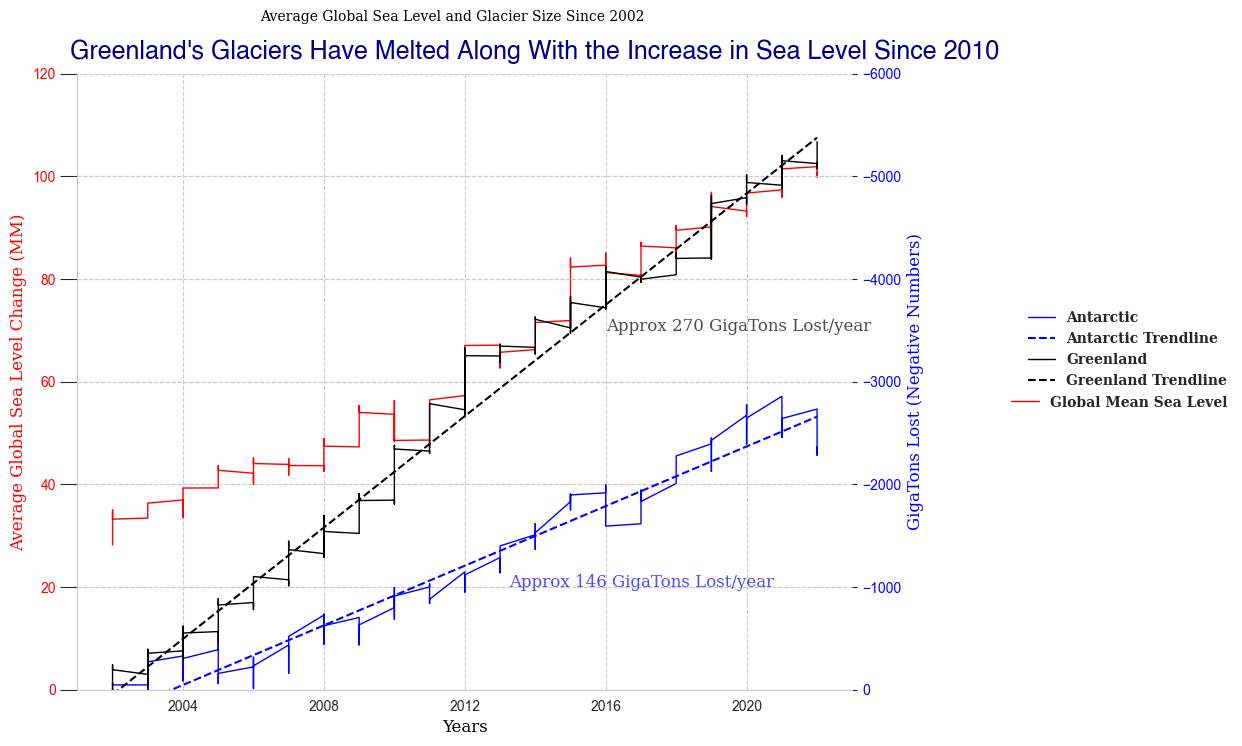

In [63]:
fig, ax1 = plt.subplots(figsize=(10, 8))
ax2 = ax1.twinx()
#sns.set_style("whitegrid", {'grid.linestyle': '--'})


#ax2.plot(hurricane['Year'], hurricane['Named Storms'], color='green', lw=2, label = 'Named Storms')
ax2.plot(glacier_df['Year'], glacier_df["Antartica_Ice_Mass_Variation"], color='blue', alpha = 1,lw=1, label = 'Antarctic')


x = glacier_df['Year']
x_num = dates.date2num(x)
trend = np.polyfit(x_num, glacier_df['Antartica_Ice_Mass_Variation'], 1)
fit = np.poly1d(trend)
x_fit = np.linspace(x_num.min(), x_num.max())
plt.plot(dates.num2date(x_fit), fit(x_fit), "b--", label = 'Antarctic Trendline')

ax2.plot(glacier_df['Year'], glacier_df['Greenland_Ice_Mass_Variation'], color='black', lw=1, label = 'Greenland')

x = glacier_df['Year']
x_num = dates.date2num(x)
trend = np.polyfit(x_num, glacier_df['Greenland_Ice_Mass_Variation'], 1)
fit = np.poly1d(trend)
x_fit = np.linspace(x_num.min(), x_num.max())
plt.plot(dates.num2date(x_fit), fit(x_fit), "k--", label = 'Greenland Trendline')

ax1.plot(sea_level3['Date'], sea_level3['Global Mean Sea Level Variation since 1993 (mm)'], color='red',alpha = 1, lw=1, label = 'Global Mean Sea Level')
plt.xticks(font = 'serif')

a = sea_level3['Date']
a_num = dates.date2num(a)
trend = np.polyfit(a_num, sea_level3['Global Mean Sea Level Variation since 1993 (mm)'], 1)
fit = np.poly1d(trend)
x_fit = np.linspace(a_num.min(), a_num.max())
#plt.plot(dates.num2date(x_fit), fit(x_fit), "r--", label = 'Temperature Trendline')

ax1.set_ylabel("Average Global Sea Level Change (MM)", color='red', fontsize=12, fontdict={'font':'serif'})
ax1.tick_params(axis="y", labelcolor='red', size = 12)
ax1.set_ylim(0,120)
#ax1.set_xlim(11000,20000)
ax2.set_ylabel("GigaTons Lost (Negative Numbers)", color='blue', fontsize=12, fontdict={'font':'serif'})
ax1.set_xlabel("Years", color='black', fontsize=12, fontdict={'font':'serif'})
ax2.tick_params(axis="y", labelcolor='blue')
ax2.set_ylim(0,-6000)
fig.suptitle("", fontsize=20)
#fig.autofmt_xdate()
ax1.legend(bbox_to_anchor=(1.5,.435),loc='lower right',prop={'weight':'bold','size':10,'family':'serif'}, frameon=False)
ax2.legend(bbox_to_anchor=(1.5,.47),loc='lower right',prop={'weight':'bold','size':10,'family':'serif'}, frameon=False)
sns.despine(bottom = False, left = False)
fig.suptitle("Average Global Sea Level and Glacier Size Since 2002", fontsize=16, font = 'serif', color='#000000',y = .96)
ax2.text(11250,-6150,"Greenland's Glaciers Have Melted Along With the Increase in Sea Level Since 2010",
        fontdict={ 'size':18,'family':'Helvetica'}, color="darkblue", alpha = 1)
ax2.text(15800,-1000,"Approx 146 GigaTons Lost/year",
      fontdict={ 'size':12,'family':'serif'}, alpha = .7, color= 'blue')
ax2.text(16800,-3500,"Approx 270 GigaTons Lost/year",
        fontdict={ 'size':12,'family':'serif'}, alpha = .7, color = 'black')
plt.show()

## Tornadoes

In [64]:
tornado_df = pd.read_excel("Tornado Dataset.xlsx")

In [65]:
tornado_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Date        73 non-null     int64
 1   Tornadoes   73 non-null     int64
 2   Fatalities  73 non-null     int64
dtypes: int64(3)
memory usage: 1.8 KB


In [66]:
tornado_df['Date'] = pd.to_datetime(tornado_df.Date, format='%Y')

In [67]:
tornado_df = tornado_df.loc[tornado_df["Date"] > "1996-01-01"]

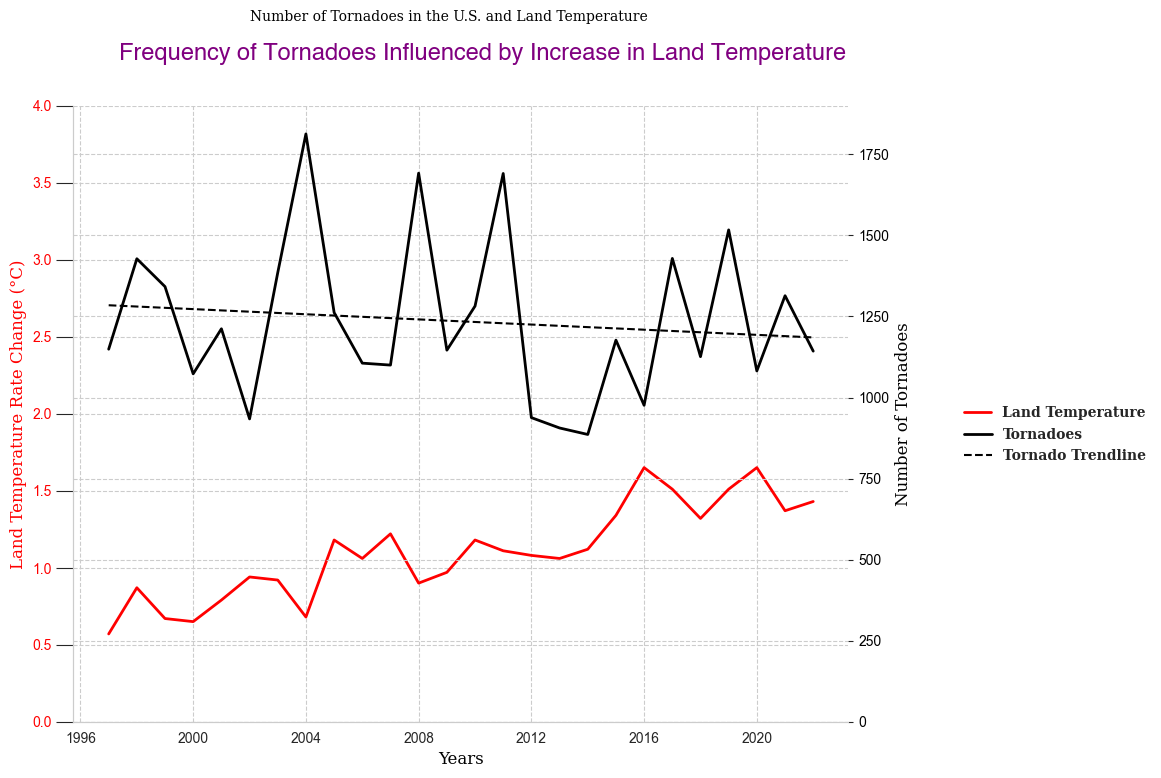

In [68]:
fig, ax1 = plt.subplots(figsize=(10, 8))
ax2 = ax1.twinx()
#sns.set_style("whitegrid", {'grid.linestyle': '--'})

ax1.plot(temp_final['Year'], temp_final['Land_Temp_Anomaly'], color='red', lw=2, label = 'Land Temperature')
#ax2.plot(hurricane['Year'], hurricane['Named Storms'], color='green', lw=2, label = 'Named Storms')
#ax2.plot(hurricane['Year'], hurricane['Hurricanes'], color='blue', alpha = 1,lw=2, label = 'Hurricanes')



ax2.plot(tornado_df['Date'], tornado_df['Tornadoes'], color='black',alpha = 1, lw=2, label = 'Tornadoes')
plt.xticks(font = 'serif')

x = tornado_df['Date']
x_num = dates.date2num(x)
trend = np.polyfit(x_num, tornado_df['Tornadoes'], 1)
fit = np.poly1d(trend)
x_fit = np.linspace(x_num.min(), x_num.max())
plt.plot(dates.num2date(x_fit), fit(x_fit), "k--", label = 'Tornado Trendline')


ax1.set_ylabel("Land Temperature Rate Change (°C)", color='red', fontsize=12, fontdict={'font':'serif'})
ax1.tick_params(axis="y", labelcolor='red', size = 12)
ax1.set_ylim(0,4)
ax2.set_ylabel("Number of Tornadoes", color='black', fontsize=12, fontdict={'font':'serif'})
ax1.set_xlabel("Years", color='black', fontsize=12, fontdict={'font':'serif'})
ax2.tick_params(axis="y", labelcolor='black')
ax2.set_ylim(0,1900)
fig.suptitle("", fontsize=20)
#fig.autofmt_xdate()
ax1.legend(bbox_to_anchor=(1.4,.47),loc='lower right',prop={'weight':'bold','size':10,'family':'serif'}, frameon=False)
ax2.legend(bbox_to_anchor=(1.4,.4),loc='lower right',prop={'weight':'bold','size':10,'family':'serif'}, frameon=False)
sns.despine(bottom = False, left = False)
fig.suptitle("Number of Tornadoes in the U.S. and Land Temperature", fontsize=16, font = 'serif', color="#000000", y = 1)
ax1.text(10000,4.3,"Frequency of Tornadoes Influenced by Increase in Land Temperature",
       fontdict={ 'size':17,'family':'Helvetica'}, color="purple", alpha = 1)
plt.show()

## Wildfire

In [69]:
wildfire_df = pd.read_csv("US Wildfire Data - Sheet1.csv")

In [70]:
wildfire_df

,Year,Fires,Acres
0,2022,"68,988","7,577,183"
1,2021,"58,985","7,125,643"
2,2020,"58,950","10,122,336"
3,2019,"50,477","4,664,364"
4,2018,"58,083","8,767,492"
5,2017,"71,499","10,026,086"
6,2016,"67,743","5,509,995"
7,2015,"68,151","10,125,149"
8,2014,"63,312","3,595,613"
9,2013,"47,579","4,319,546"


In [71]:
wildfire_df = wildfire_df.loc[wildfire_df["Year"] > 1996]

In [72]:
wildfire_df['Year'] = pd.to_datetime(wildfire_df.Year, format='%Y')

/var/folders/6m/d853x4qs7139b3m7ydxp7jfm0000gn/T/ipykernel_95166/2677421907.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wildfire_df['Year'] = pd.to_datetime(wildfire_df.Year, format='%Y')


In [73]:
wildfire_df.replace(',', '', regex=True, inplace=True)

/var/folders/6m/d853x4qs7139b3m7ydxp7jfm0000gn/T/ipykernel_95166/448534138.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wildfire_df.replace(',', '', regex=True, inplace=True)


In [74]:
wildfire_df = wildfire_df.astype({'Fires': 'int', 'Acres': 'int'})

In [75]:
wildfire_df

,Year,Fires,Acres
0,2022-01-01,68988,7577183
1,2021-01-01,58985,7125643
2,2020-01-01,58950,10122336
3,2019-01-01,50477,4664364
4,2018-01-01,58083,8767492
5,2017-01-01,71499,10026086
6,2016-01-01,67743,5509995
7,2015-01-01,68151,10125149
8,2014-01-01,63312,3595613
9,2013-01-01,47579,4319546


### Fires

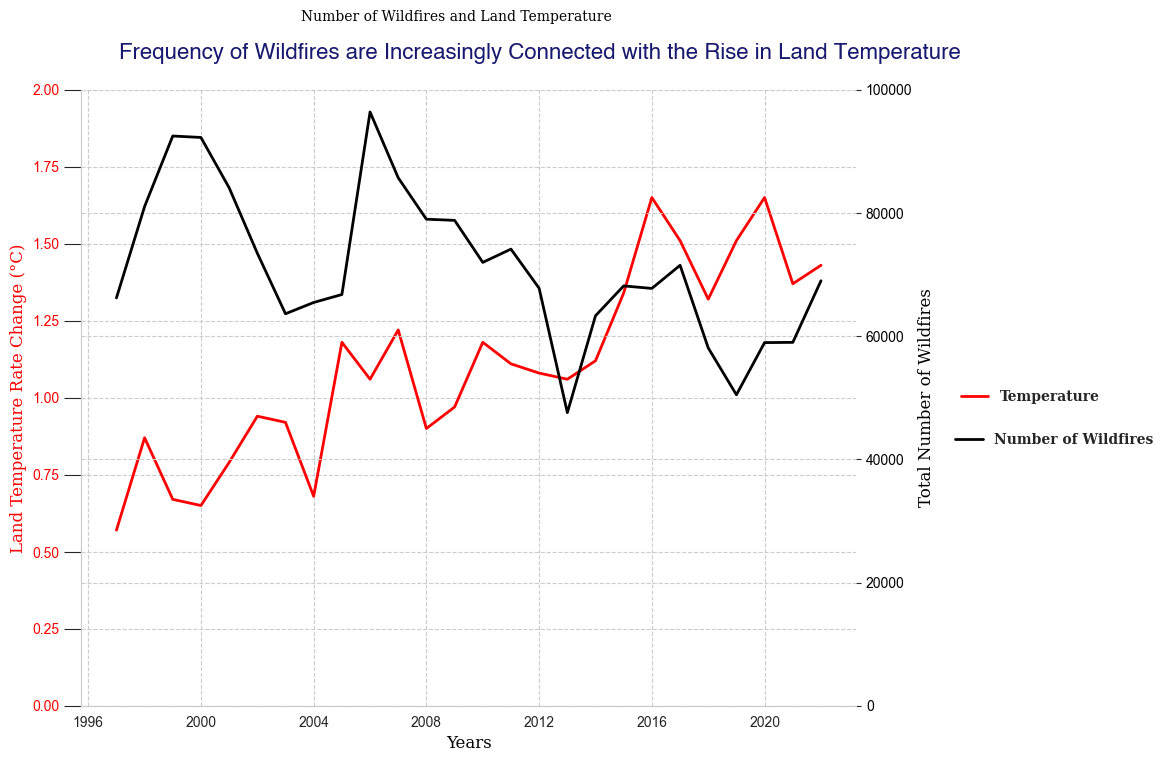

In [76]:
fig, ax1 = plt.subplots(figsize=(10, 8))
ax2 = ax1.twinx()
#sns.set_style("whitegrid", {'grid.linestyle': '--'})

ax1.plot(temp_final['Year'], temp_final['Land_Temp_Anomaly'], color='red', lw=2, label = 'Temperature')
#ax2.plot(hurricane['Year'], hurricane['Named Storms'], color='green', lw=2, label = 'Named Storms')
#ax2.plot(hurricane['Year'], hurricane['Hurricanes'], color='blue', alpha = 1,lw=2, label = 'Hurricanes')



ax2.plot(wildfire_df['Year'], wildfire_df['Fires'], color='black',alpha = 1, lw=2, label = 'Number of Wildfires')
plt.xticks(font = 'serif')

x = wildfire_df['Year']
x_num = dates.date2num(x)
trend = np.polyfit(x_num, wildfire_df['Fires'], 1)
fit = np.poly1d(trend)
x_fit = np.linspace(x_num.min(), x_num.max())
#plt.plot(dates.num2date(x_fit), fit(x_fit), "k--", label = 'ACE Trendline')


ax1.set_ylabel("Land Temperature Rate Change (°C)", color='red', fontsize=12, fontdict={'font':'serif'})
ax1.tick_params(axis="y", labelcolor='red', size = 12)
ax1.set_ylim(0,2)
ax2.set_ylabel("Total Number of Wildfires", color='black', fontsize=12, fontdict={'font':'serif'})
ax1.set_xlabel("Years", color='black', fontsize=12, fontdict={'font':'serif'})
ax2.tick_params(axis="y", labelcolor='black')
ax2.set_ylim(0,100000)
fig.suptitle("", fontsize=20)
#fig.autofmt_xdate()
ax1.legend(bbox_to_anchor=(1.33,.47),loc='lower right',prop={'weight':'bold','size':10,'family':'serif'}, frameon=False)
ax2.legend(bbox_to_anchor=(1.4,.4),loc='lower right',prop={'weight':'bold','size':10,'family':'serif'}, frameon=False)
sns.despine(bottom = False, left = False)
fig.suptitle("Number of Wildfires and Land Temperature", fontsize=16, font = 'serif', color="#000000", y = .98)
ax1.text(9900,2.1,"Frequency of Wildfires are Increasingly Connected with the Rise in Land Temperature",
       fontdict={ 'size':16,'family':'Helvetica'}, color="midnightblue", alpha = 1)
plt.show()

### Acres

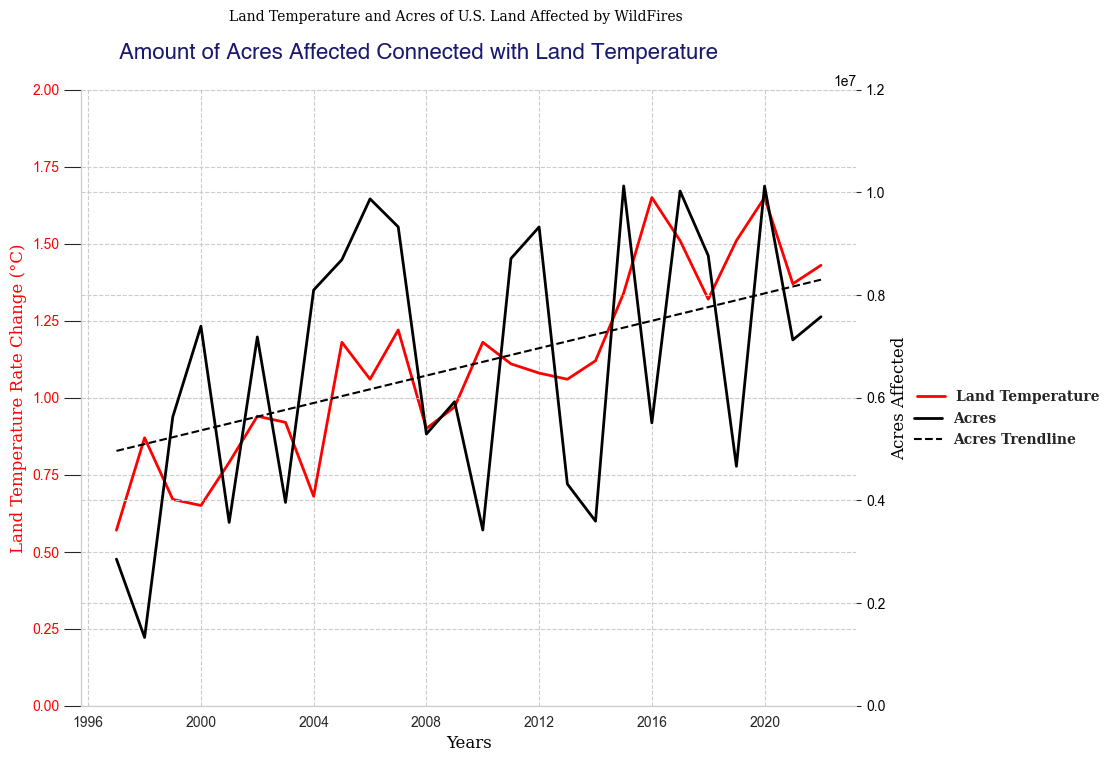

In [77]:
fig, ax1 = plt.subplots(figsize=(10, 8))
ax2 = ax1.twinx()
#sns.set_style("whitegrid", {'grid.linestyle': '--'})

ax1.plot(temp_final['Year'], temp_final['Land_Temp_Anomaly'], color='red', lw=2, label = 'Land Temperature')
#ax2.plot(hurricane['Year'], hurricane['Named Storms'], color='green', lw=2, label = 'Named Storms')
#ax2.plot(hurricane['Year'], hurricane['Hurricanes'], color='blue', alpha = 1,lw=2, label = 'Hurricanes')



ax2.plot(wildfire_df['Year'], wildfire_df['Acres'], color='black',alpha = 1, lw=2, label = 'Acres')
plt.xticks(font = 'serif')

x = wildfire_df['Year']
x_num = dates.date2num(x)
trend = np.polyfit(x_num, wildfire_df['Acres'], 1)
fit = np.poly1d(trend)
x_fit = np.linspace(x_num.min(), x_num.max())
plt.plot(dates.num2date(x_fit), fit(x_fit), "k--", label = 'Acres Trendline')


ax1.set_ylabel("Land Temperature Rate Change (°C)", color='red', fontsize=12, fontdict={'font':'serif'})
ax1.tick_params(axis="y", labelcolor='red', size = 12)
ax1.set_ylim(0,2)
ax2.set_ylabel("Acres Affected", color='black', fontsize=12, fontdict={'font':'serif'})
ax1.set_xlabel("Years", color='black', fontsize=12, fontdict={'font':'serif'})
ax2.tick_params(axis="y", labelcolor='black')
ax2.set_ylim(0,12000000)
fig.suptitle("", fontsize=20)
#fig.autofmt_xdate()
ax1.legend(bbox_to_anchor=(1.33,.47),loc='lower right',prop={'weight':'bold','size':10,'family':'serif'}, frameon=False)
ax2.legend(bbox_to_anchor=(1.3,.4),loc='lower right',prop={'weight':'bold','size':10,'family':'serif'}, frameon=False)
sns.despine(bottom = False, left = False)
fig.suptitle("Land Temperature and Acres of U.S. Land Affected by WildFires", fontsize=16, font = 'serif', color="#000000", y = .98)
ax1.text(9900,2.1,"Amount of Acres Affected Connected with Land Temperature",
       fontdict={ 'size':16,'family':'Helvetica'}, color="midnightblue", alpha = 1)
plt.show()

## References

* https://www.nasa.gov/stem-content/antarctic-ice-mass-data-set/

* https://tropical.atmos.colostate.edu/Realtime/index.php?arch&loc=global

* https://www.nifc.gov/fire-information/statistics/wildfires

* https://www.statista.com/statistics/276629/global-co2-emissions/#:~:text=Global%20carbon%20dioxide%20emissions%20from,by%20more%20than%2060%20percent

* https://climate.nasa.gov/vital-signs/carbon-dioxide/

* https://climate.nasa.gov/vital-signs/global-temperature/

* https://gml.noaa.gov/ccgg/trends/gl_gr.html

* https://www.emdat.be/

* https://www.nasa.gov/stem-content/sea-level-height-data-set/



